# Final Results & SHAP Demo — Credit Risk Scoring

This notebook pulls together the outcome of the full pipeline (`src/data_preprocessing.py` →
`src/feature_engineering.py` → `src/train_models.py` → `src/evaluate.py` → `src/inference.py`):
model comparison, hyperparameter tuning, final test-set evaluation, SHAP interpretability, and a
live demo of the `predict()` API.

Nothing here duplicates logic from `src/` — every plot and number below is produced by actually
calling the real project code, not by re-describing it.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from src.config import (
    FEATURES_TEST_PATH, TARGET_COL, REPORTS_DIR, FIGURES_DIR, FINAL_MODEL_PATH,
)
from src.evaluate import (
    load_final_model, load_train_test, get_oof_probabilities, find_best_threshold_by_cost,
    evaluate_at_threshold, plot_roc_and_pr_curves, plot_confusion_matrix, plot_threshold_cost_curve,
)
from src.inference import (
    CreditRiskPredictor, plot_global_summary, plot_client_waterfall, select_representative_clients,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 1. Model comparison recap

4 model families × 2 class-imbalance strategies, compared via 5-fold stratified CV on the training set
(see `src/train_models.py` for the full methodology and rationale). Loaded here, not recomputed — the
full comparison takes several minutes (dominated by Random Forest).

In [2]:
comparison_df = pd.read_csv(REPORTS_DIR / "model_comparison.csv")
comparison_df = comparison_df.sort_values("pr_auc_mean", ascending=False).reset_index(drop=True)
comparison_df

,model,imbalance_strategy,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,precision_mean,recall_mean,f1_mean,fit_time_seconds
0,lightgbm,class_weight,0.862553,0.003664,0.395588,0.006095,0.224044,0.757636,0.345819,5.8
1,logistic_regression,class_weight,0.857002,0.003483,0.380932,0.005330,0.215684,0.749781,0.334990,1.6
2,logistic_regression,smote,0.856432,0.003196,0.379415,0.005581,0.215182,0.752648,0.334672,3.4
3,lightgbm,smote,0.856421,0.003766,0.379403,0.005023,0.534154,0.238001,0.329160,13.3
4,xgboost,class_weight,0.841718,0.004106,0.362923,0.012589,0.238461,0.674230,0.352299,4.5
5,xgboost,smote,0.849461,0.004123,0.360011,0.010506,0.520550,0.211570,0.300717,9.1
6,random_forest,class_weight,0.834301,0.003065,0.339805,0.005252,0.539474,0.148235,0.232313,87.4
7,random_forest,smote,0.831955,0.003192,0.321051,0.006173,0.455383,0.256700,0.328158,172.2


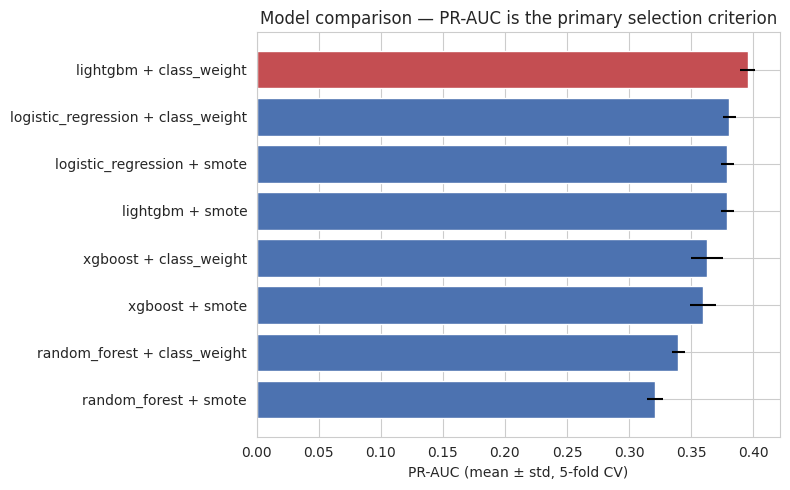

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = comparison_df["model"] + " + " + comparison_df["imbalance_strategy"]
colors = ["#C44E52" if i == 0 else "#4C72B0" for i in range(len(comparison_df))]
ax.barh(labels, comparison_df["pr_auc_mean"], xerr=comparison_df["pr_auc_std"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("PR-AUC (mean ± std, 5-fold CV)")
ax.set_title("Model comparison — PR-AUC is the primary selection criterion")
plt.tight_layout()
plt.show()

**LightGBM + class weighting wins** on PR-AUC (the primary criterion for this imbalanced problem —
see `src/train_models.py` for why PR-AUC rather than accuracy or F1 was used to pick the winner). Full
discussion of *why* class weighting and SMOTE behave so differently is in the main README.

## 2. Hyperparameter tuning (Optuna)

30-trial Optuna study (TPE sampler) on the winning configuration, same CV + PR-AUC objective as the
comparison stage above.

In [4]:
with open(REPORTS_DIR / "best_hyperparams.json") as f:
    tuning_result = json.load(f)

print(f"Default hyperparameters CV PR-AUC: {tuning_result['default_cv_pr_auc']:.4f}")
print(f"Optuna-tuned CV PR-AUC:            {tuning_result['best_cv_pr_auc']:.4f}")
print()
print("Best hyperparameters found:")
for k, v in tuning_result["params"].items():
    print(f"  {k}: {v}")

Default hyperparameters CV PR-AUC: 0.3956
Optuna-tuned CV PR-AUC:            0.4018

Best hyperparameters found:
  n_estimators: 108
  num_leaves: 67
  max_depth: 5
  learning_rate: 0.055363451780895905
  min_child_samples: 43
  subsample: 0.8665991722022603
  colsample_bytree: 0.821103479582126
  reg_alpha: 0.07461541434193558
  reg_lambda: 6.135465318705152


The gain here is modest (+1.6% relative PR-AUC) rather than dramatic — LightGBM's defaults are
already strong on tabular data like this, so tuning refines rather than transforms performance. Worth
saying plainly rather than overselling it.

## 3. Final evaluation on the held-out test set

This is the **only** place the test set (30,000 rows) is used — for reporting, after every modeling
decision (model family, imbalance strategy, hyperparameters, and the decision threshold below) was made
using cross-validation on the training set only.

In [5]:
model = load_final_model()
X_train, y_train, X_test, y_test = load_train_test()

y_test_probs = model.predict_proba(X_test)[:, 1]

with open(REPORTS_DIR / "final_evaluation.json") as f:
    final_eval = json.load(f)

chosen_threshold = final_eval["chosen_threshold"]
print(f"Chosen decision threshold (cost-minimizing, selected via train-only OOF predictions): {chosen_threshold:.2f}")
print()
print("At default threshold 0.50:", final_eval["metrics_at_default_threshold_0.5"])
print("At chosen threshold:      ", final_eval["metrics_at_chosen_threshold"])

Chosen decision threshold (cost-minimizing, selected via train-only OOF predictions): 0.72

At default threshold 0.50: {'threshold': 0.5, 'roc_auc': 0.8698180339471023, 'pr_auc': 0.40222315186982305, 'precision': 0.21810870770937327, 'recall': 0.7845386533665836, 'f1': 0.34132581100141046}
At chosen threshold:       {'threshold': 0.72, 'roc_auc': 0.8698180339471023, 'pr_auc': 0.40222315186982305, 'precision': 0.35462081670248696, 'recall': 0.5760598503740648, 'f1': 0.43899657924743446}


2026-07-09 12:37:41,672 | INFO | Saved ROC/PR curves to /home/claude/credit-risk-scoring/reports/figures/roc_pr_curves.png


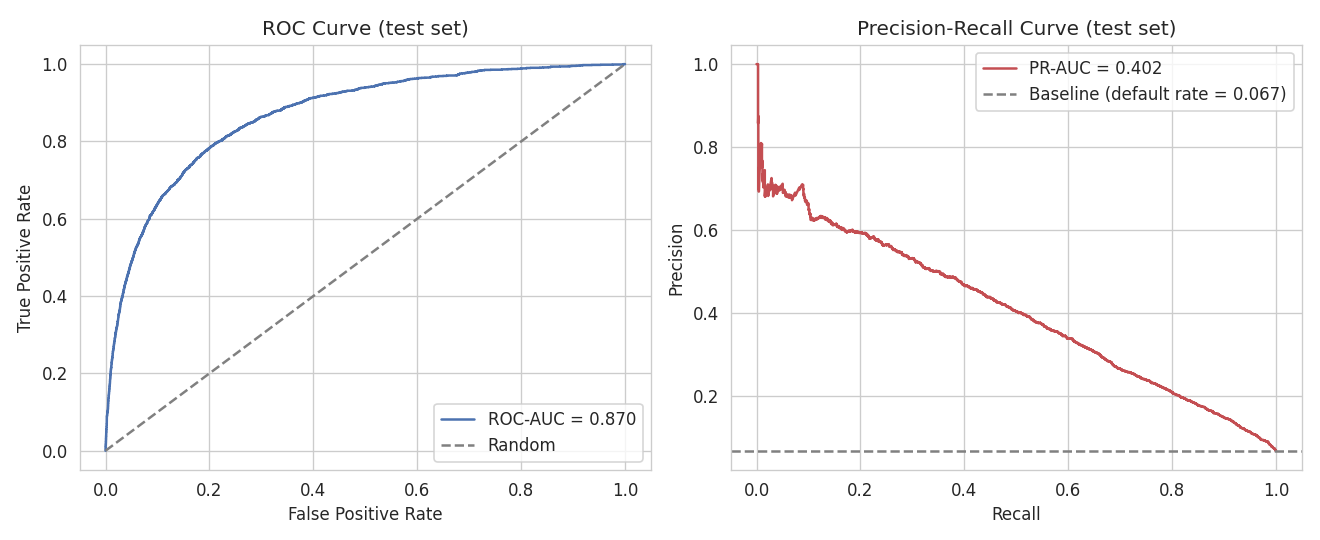

In [6]:
plot_roc_and_pr_curves(y_test, y_test_probs, FIGURES_DIR / "roc_pr_curves.png")
display(Image(filename=str(FIGURES_DIR / "roc_pr_curves.png")))

**ROC-AUC = 0.870, PR-AUC = 0.402** on genuinely held-out data — consistent with the CV estimate
from the comparison stage, confirming no leakage or overfitting crept in anywhere upstream.

2026-07-09 12:37:41,811 | INFO | Saved confusion matrix to /home/claude/credit-risk-scoring/reports/figures/confusion_matrix.png


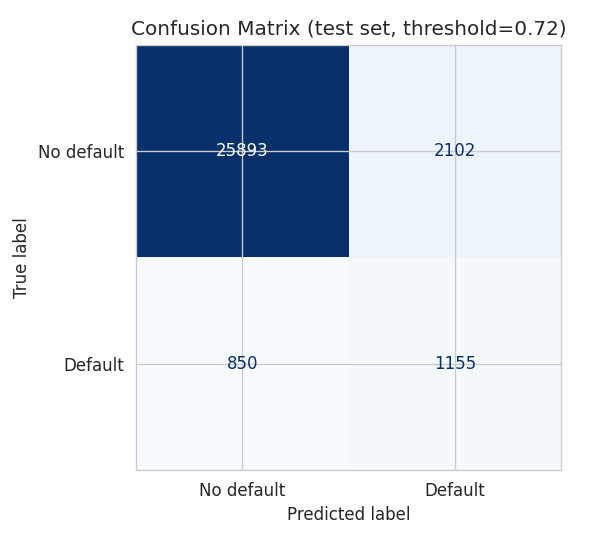

In [7]:
plot_confusion_matrix(y_test, y_test_probs, chosen_threshold, FIGURES_DIR / "confusion_matrix.png")
display(Image(filename=str(FIGURES_DIR / "confusion_matrix.png")))

### Why the chosen threshold (0.72) is *higher* than the naive default (0.5)

The threshold was picked using **out-of-fold predictions on the training set only** (never the test
set — threshold selection is itself a modeling decision), minimizing an illustrative cost of
`5 × missed_defaults + 1 × wrongly_declined_borrowers`. This 5:1 ratio reflects the common credit-risk
heuristic that a missed default costs a lender far more (losing a large share of loan principal) than
declining a good borrower (losing only that one loan's profit margin) — illustrative of the
methodology, not a claim about any specific lender's real figures.

2026-07-09 12:37:50,751 | INFO | Saved threshold cost curve to /home/claude/credit-risk-scoring/reports/figures/threshold_cost_curve.png


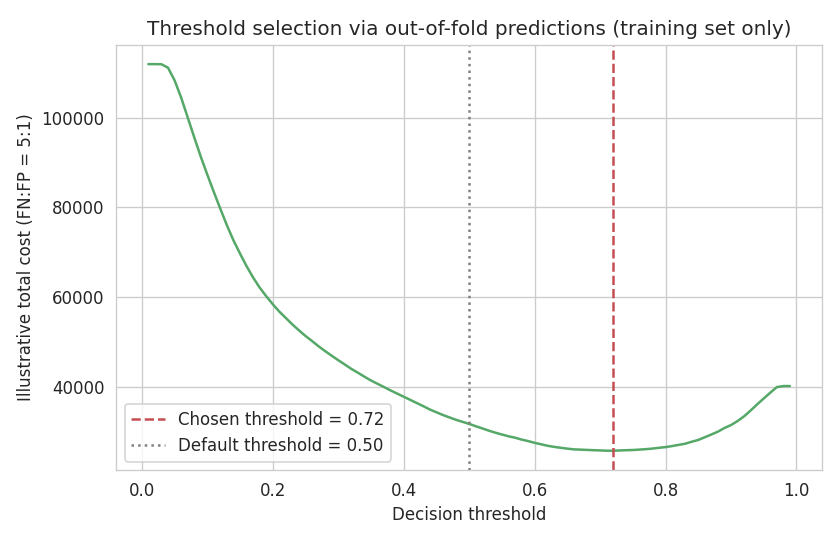

In [8]:
oof_probs = get_oof_probabilities(model, X_train, y_train)
best_threshold, thresholds, costs = find_best_threshold_by_cost(y_train, oof_probs)
plot_threshold_cost_curve(thresholds, costs, best_threshold, FIGURES_DIR / "threshold_cost_curve.png")
display(Image(filename=str(FIGURES_DIR / "threshold_cost_curve.png")))

Counter-intuitive finding: the cost-minimizing threshold is *higher* than 0.5, not lower. Because
`class_weight="balanced"` already pushed the model to flag risk aggressively during training, recall at
the default 0.5 threshold is already high (78.5%) but precision is low (21.8%) — and since non-defaulters
outnumber defaulters roughly 14:1, even a moderate false-positive *rate* means a large absolute number of
wrongly-declined good borrowers. Raising the threshold trades away some recall but cuts false positives
enough that total cost goes down even while weighting missed defaults 5x as heavily.

## 4. SHAP — global feature importance

SHAP values are computed in **probability space** (percentage points of risk), not the default log-odds
`TreeExplainer` normally returns, since that's what's actually interpretable to a non-technical audience
— see `src/inference.py` for the `feature_perturbation="interventional"` setup this requires.

2026-07-09 12:37:53,679 | INFO | Saved global SHAP summary plot to /home/claude/credit-risk-scoring/reports/figures/shap_summary.png (n=500)


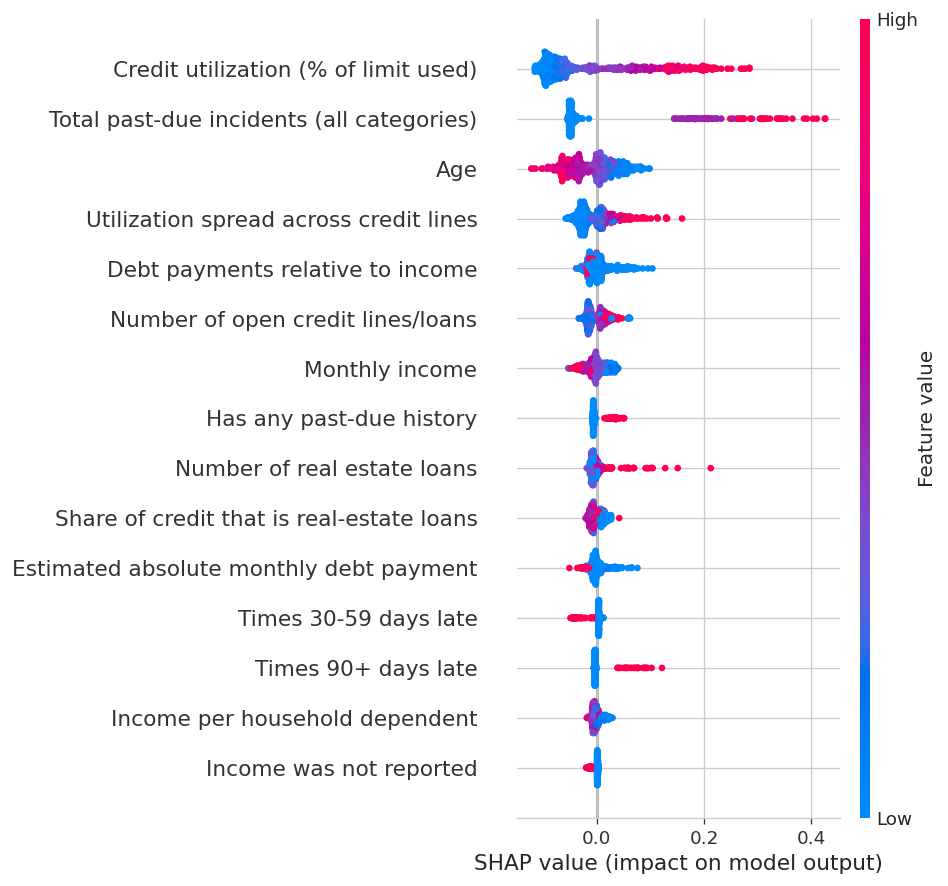

In [9]:
predictor = CreditRiskPredictor()
plot_global_summary(predictor, X_test, FIGURES_DIR / "shap_summary.png")
display(Image(filename=str(FIGURES_DIR / "shap_summary.png")))

Consistent with EDA and feature engineering findings: past-due history and credit utilization
dominate; income and real-estate features play a smaller, secondary role.

## 5. SHAP — four individual clients, four different stories

Four clients, chosen to cover different situations:

In [10]:
with open(REPORTS_DIR / "shap_client_examples.json") as f:
    client_examples = json.load(f)

clients = select_representative_clients(model, X_test, y_test, chosen_threshold)
for name, idx in clients.items():
    info = client_examples[name]
    print(f"{name}: P(default)={info['predicted_probability']:.1%}, actual={'defaulted' if info['actual_label'] else 'no default'}")
    for factor in info["top_factors"]:
        print(f"    {factor['feature']}: {factor['impact_percentage_points']:+.2f} pp")
    print()

highest_risk_client: P(default)=97.6%, actual=defaulted
    Total past-due incidents (all categories): +31.35 pp
    Credit utilization (% of limit used): +11.26 pp
    Times 90+ days late: +7.49 pp

lowest_risk_client: P(default)=3.2%, actual=no default
    Credit utilization (% of limit used): -8.67 pp
    Age: -5.57 pp
    Total past-due incidents (all categories): -4.48 pp

borderline_client: P(default)=72.0%, actual=no default
    Total past-due incidents (all categories): +28.36 pp
    Age: +8.12 pp
    Credit utilization (% of limit used): -4.29 pp

missed_default_client: P(default)=4.1%, actual=defaulted
    Credit utilization (% of limit used): -8.59 pp
    Age: -5.40 pp
    Total past-due incidents (all categories): -4.77 pp



2026-07-09 12:37:54,533 | INFO | Saved waterfall plot to /home/claude/credit-risk-scoring/reports/figures/shap_waterfall_highest_risk_client.png


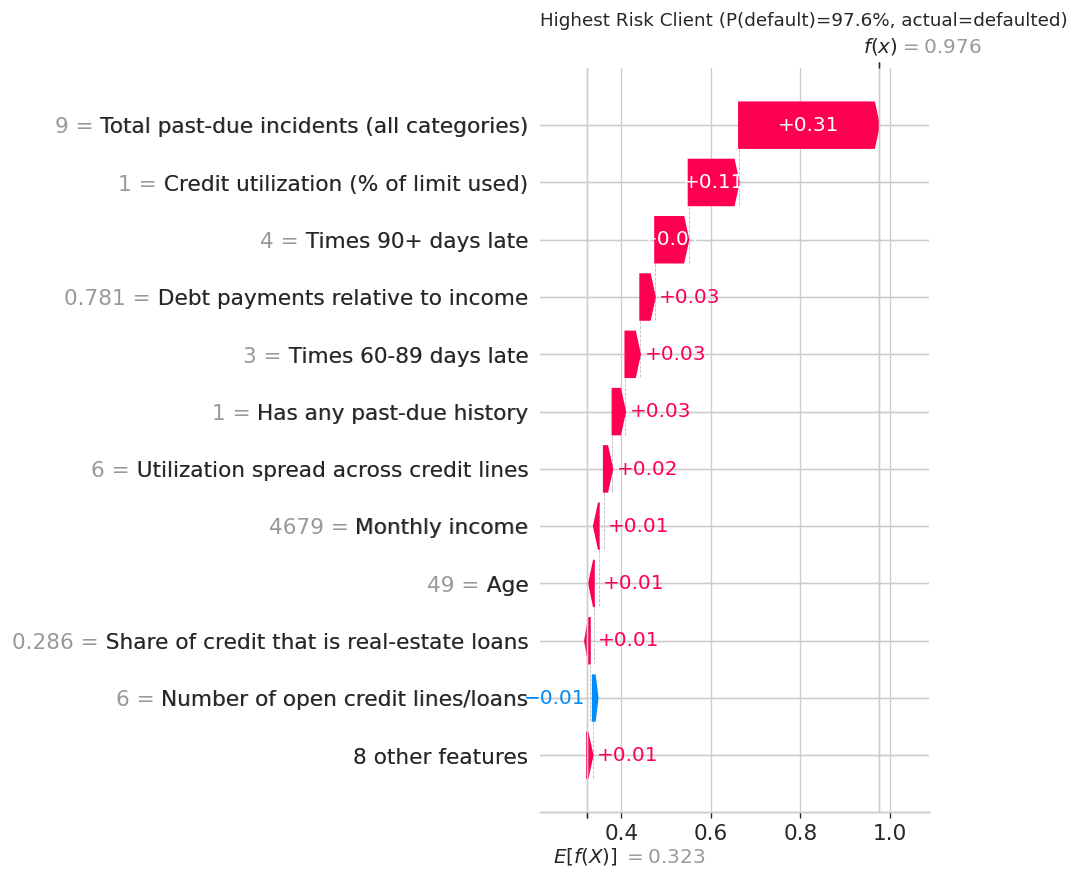

2026-07-09 12:37:55,121 | INFO | Saved waterfall plot to /home/claude/credit-risk-scoring/reports/figures/shap_waterfall_lowest_risk_client.png


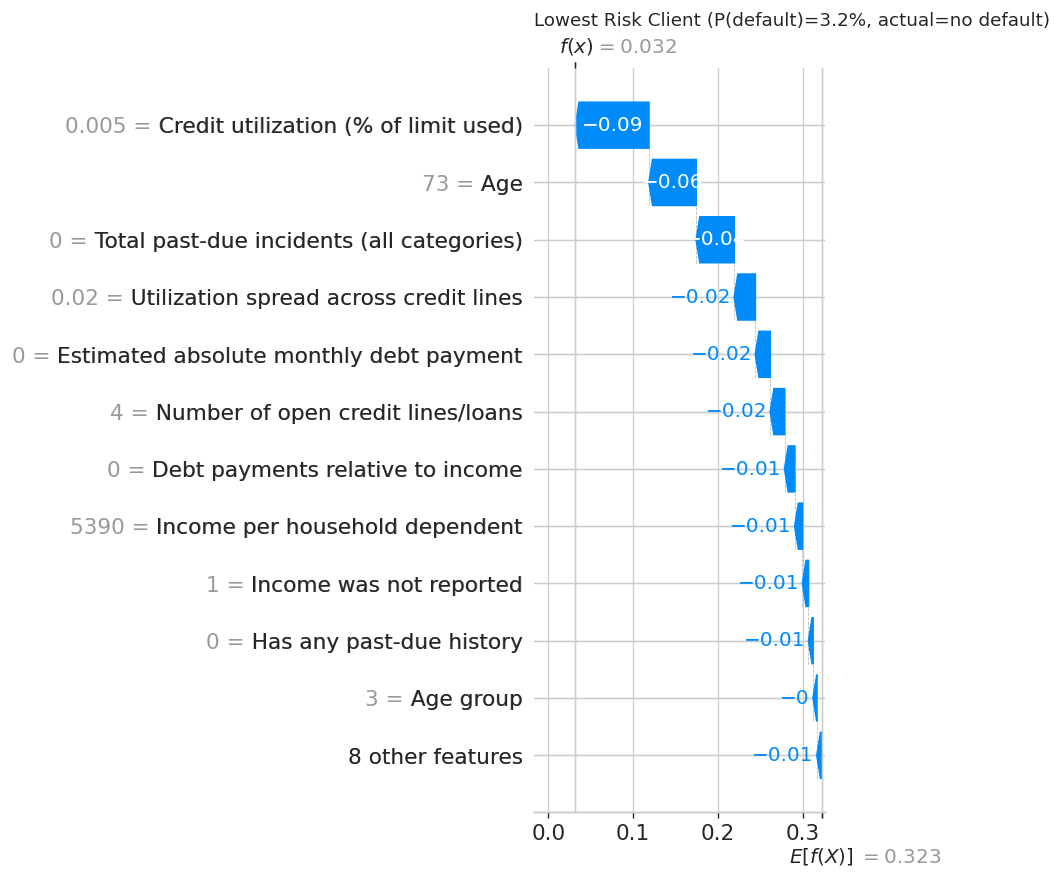

2026-07-09 12:37:55,708 | INFO | Saved waterfall plot to /home/claude/credit-risk-scoring/reports/figures/shap_waterfall_borderline_client.png


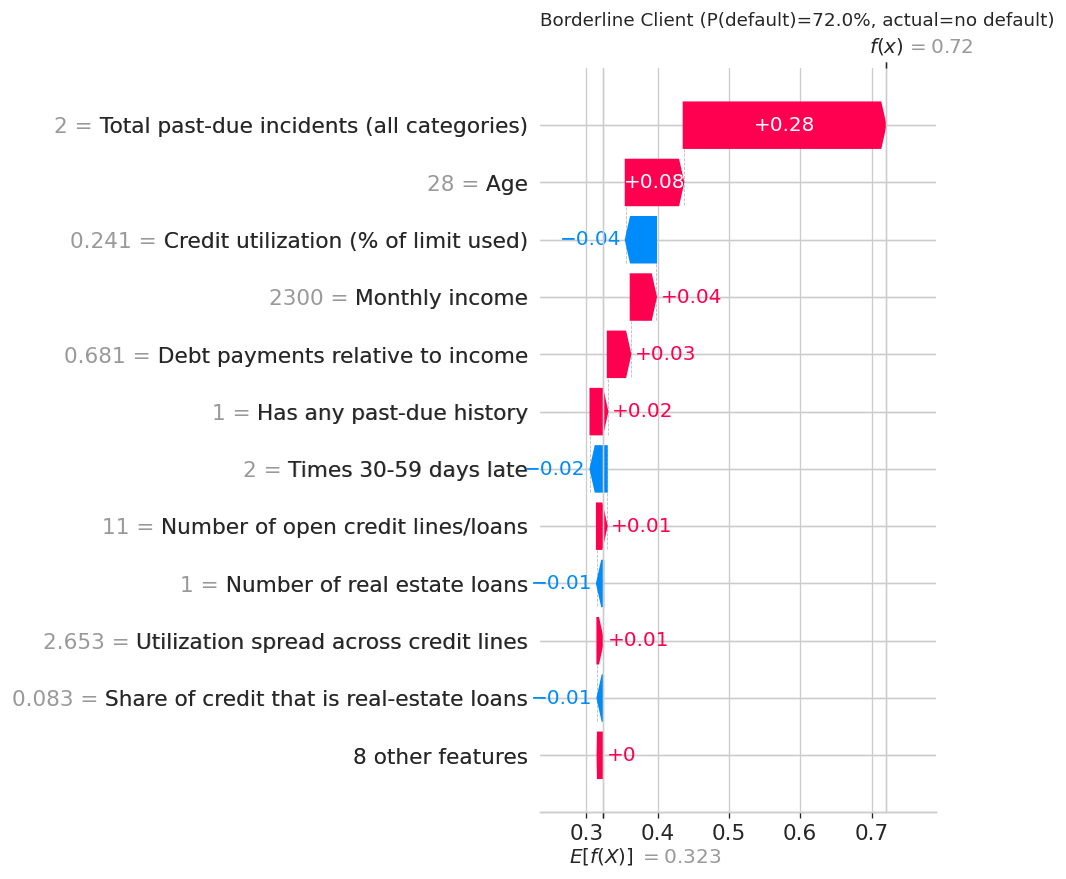

2026-07-09 12:37:56,540 | INFO | Saved waterfall plot to /home/claude/credit-risk-scoring/reports/figures/shap_waterfall_missed_default_client.png


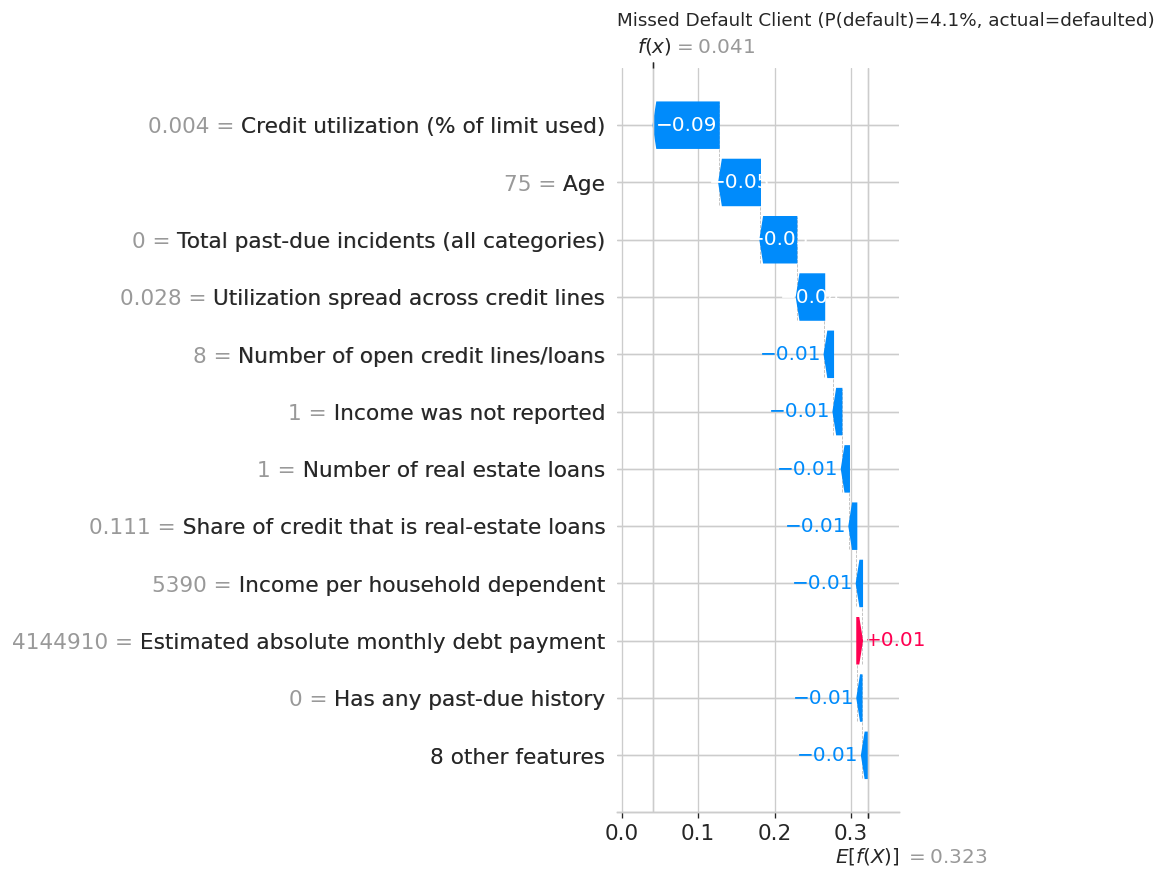

In [11]:
for name, idx in clients.items():
    row = X_test.iloc[idx]
    info = client_examples[name]
    title = f"{name.replace('_', ' ').title()} (P(default)={info['predicted_probability']:.1%}, actual={'defaulted' if info['actual_label'] else 'no default'})"
    save_path = FIGURES_DIR / f"shap_waterfall_{name}.png"
    plot_client_waterfall(predictor, row, title, save_path)
    display(Image(filename=str(save_path)))

The **borderline client** (72.0% predicted, no actual default) illustrates the cost of the 0.72
threshold directly: some genuinely good borrowers sit right at that boundary and get declined. The
**missed default** (4.1% predicted, actual default) shows the opposite failure mode — the model scored
this borrower as safe based on unremarkable utilization and past-due history, and was wrong. Not every
default is predictable from this feature set.

## 6. Live demo — `predict()` on a new, hypothetical client

This is the production-facing API: raw client fields in, probability + ranked explanation out. Same
`DataCleaner` and `FeatureEngineer` used during training, no separate/duplicated logic.

In [12]:
demo_client = {
    "RevolvingUtilizationOfUnsecuredLines": 0.85,
    "age": 29,
    "NumberOfTime30-59DaysPastDueNotWorse": 2,
    "DebtRatio": 0.6,
    "MonthlyIncome": 2800,
    "NumberOfOpenCreditLinesAndLoans": 4,
    "NumberOfTimes90DaysLate": 0,
    "NumberRealEstateLoansOrLines": 0,
    "NumberOfTime60-89DaysPastDueNotWorse": 0,
    "NumberOfDependents": 2,
}

result = predictor.predict(demo_client)
print(f"Predicted default probability: {result['default_probability']:.1%}")
print(f"Base rate: {result['base_rate_percentage_points']:.1f} percentage points")
print()
print("Top contributing factors:")
for factor in result["top_factors"]:
    print(f"  {factor['feature']}: {factor['impact_percentage_points']:+.2f} pp  (value: {factor['value']})")

Predicted default probability: 84.2%
Base rate: 32.3 percentage points

Top contributing factors:
  Total past-due incidents (all categories): +24.95 pp  (value: 2.0)
  Credit utilization (% of limit used): +13.42 pp  (value: 0.85)
  Age: +4.36 pp  (value: 29.0)
  Monthly income: +2.79 pp  (value: 2800.0)
  Has any past-due history: +2.29 pp  (value: 1.0)
  Income per household dependent: +2.12 pp  (value: 933.3333333333334)
  Debt payments relative to income: +1.61 pp  (value: 0.6)
  Share of credit that is real-estate loans: +1.34 pp  (value: 0.0)


A 29-year-old with 85% credit utilization, 2 recent late payments, and modest income relative to
2 dependents comes out at ~84% predicted default risk — driven mainly by the past-due history and
utilization, with youth and low income-per-dependent adding smaller secondary contributions. This
matches the intuition a credit analyst would have looking at the same profile manually, which is
itself a useful sanity check on the model.

## Summary

| | |
|---|---|
| **Best model** | LightGBM + class weighting (Optuna-tuned) |
| **Test ROC-AUC** | 0.870 |
| **Test PR-AUC** | 0.402 |
| **Chosen decision threshold** | 0.72 (cost-driven, not the default 0.5) |
| **Precision / Recall / F1 @ 0.72** | 0.355 / 0.576 / 0.439 |

See the main `README.md` for the full write-up, all methodological decisions, and what's worth
discussing about this project in an interview.